In [1]:
import pandas as pd
df = pd.read_csv("Water_Quality_Dataset.csv")

In [2]:
df.head()

,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level
0,2024-01-01 00:00:00,L4,8.762414,14.468306,16.461631,6.258335,2.478582,0.002801,0.001924,0.018769,2
1,2024-01-01 01:00:00,L5,7.477966,1.905645,27.446865,2.826120,8.048453,0.019551,0.000633,0.003708,2
2,2024-01-01 02:00:00,L3,7.938278,1.889506,34.623557,3.380191,2.102481,0.019291,0.000205,0.005055,2
3,2024-01-01 03:00:00,L5,8.728748,0.736115,18.802153,6.543794,6.714160,0.003358,0.001058,0.005638,2
4,2024-01-01 04:00:00,L5,7.975335,19.151777,30.851902,4.370861,2.114614,0.006059,0.000124,0.001237,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         1000 non-null   str    
 1   Location          1000 non-null   str    
 2   pH                1000 non-null   float64
 3   Turbidity (NTU)   1000 non-null   float64
 4   Temperature (°C)  1000 non-null   float64
 5   DO (mg/L)         1000 non-null   float64
 6   BOD (mg/L)        1000 non-null   float64
 7   Lead (mg/L)       1000 non-null   float64
 8   Mercury (mg/L)    1000 non-null   float64
 9   Arsenic (mg/L)    1000 non-null   float64
 10  Pollution_Level   1000 non-null   int64  
dtypes: float64(8), int64(1), str(2)
memory usage: 106.6 KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df['Timestamp']=pd.to_datetime(df['Timestamp'])

In [6]:
df['Timestamp'].dtype
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

In [7]:
df = df.drop(columns=["Location"])

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

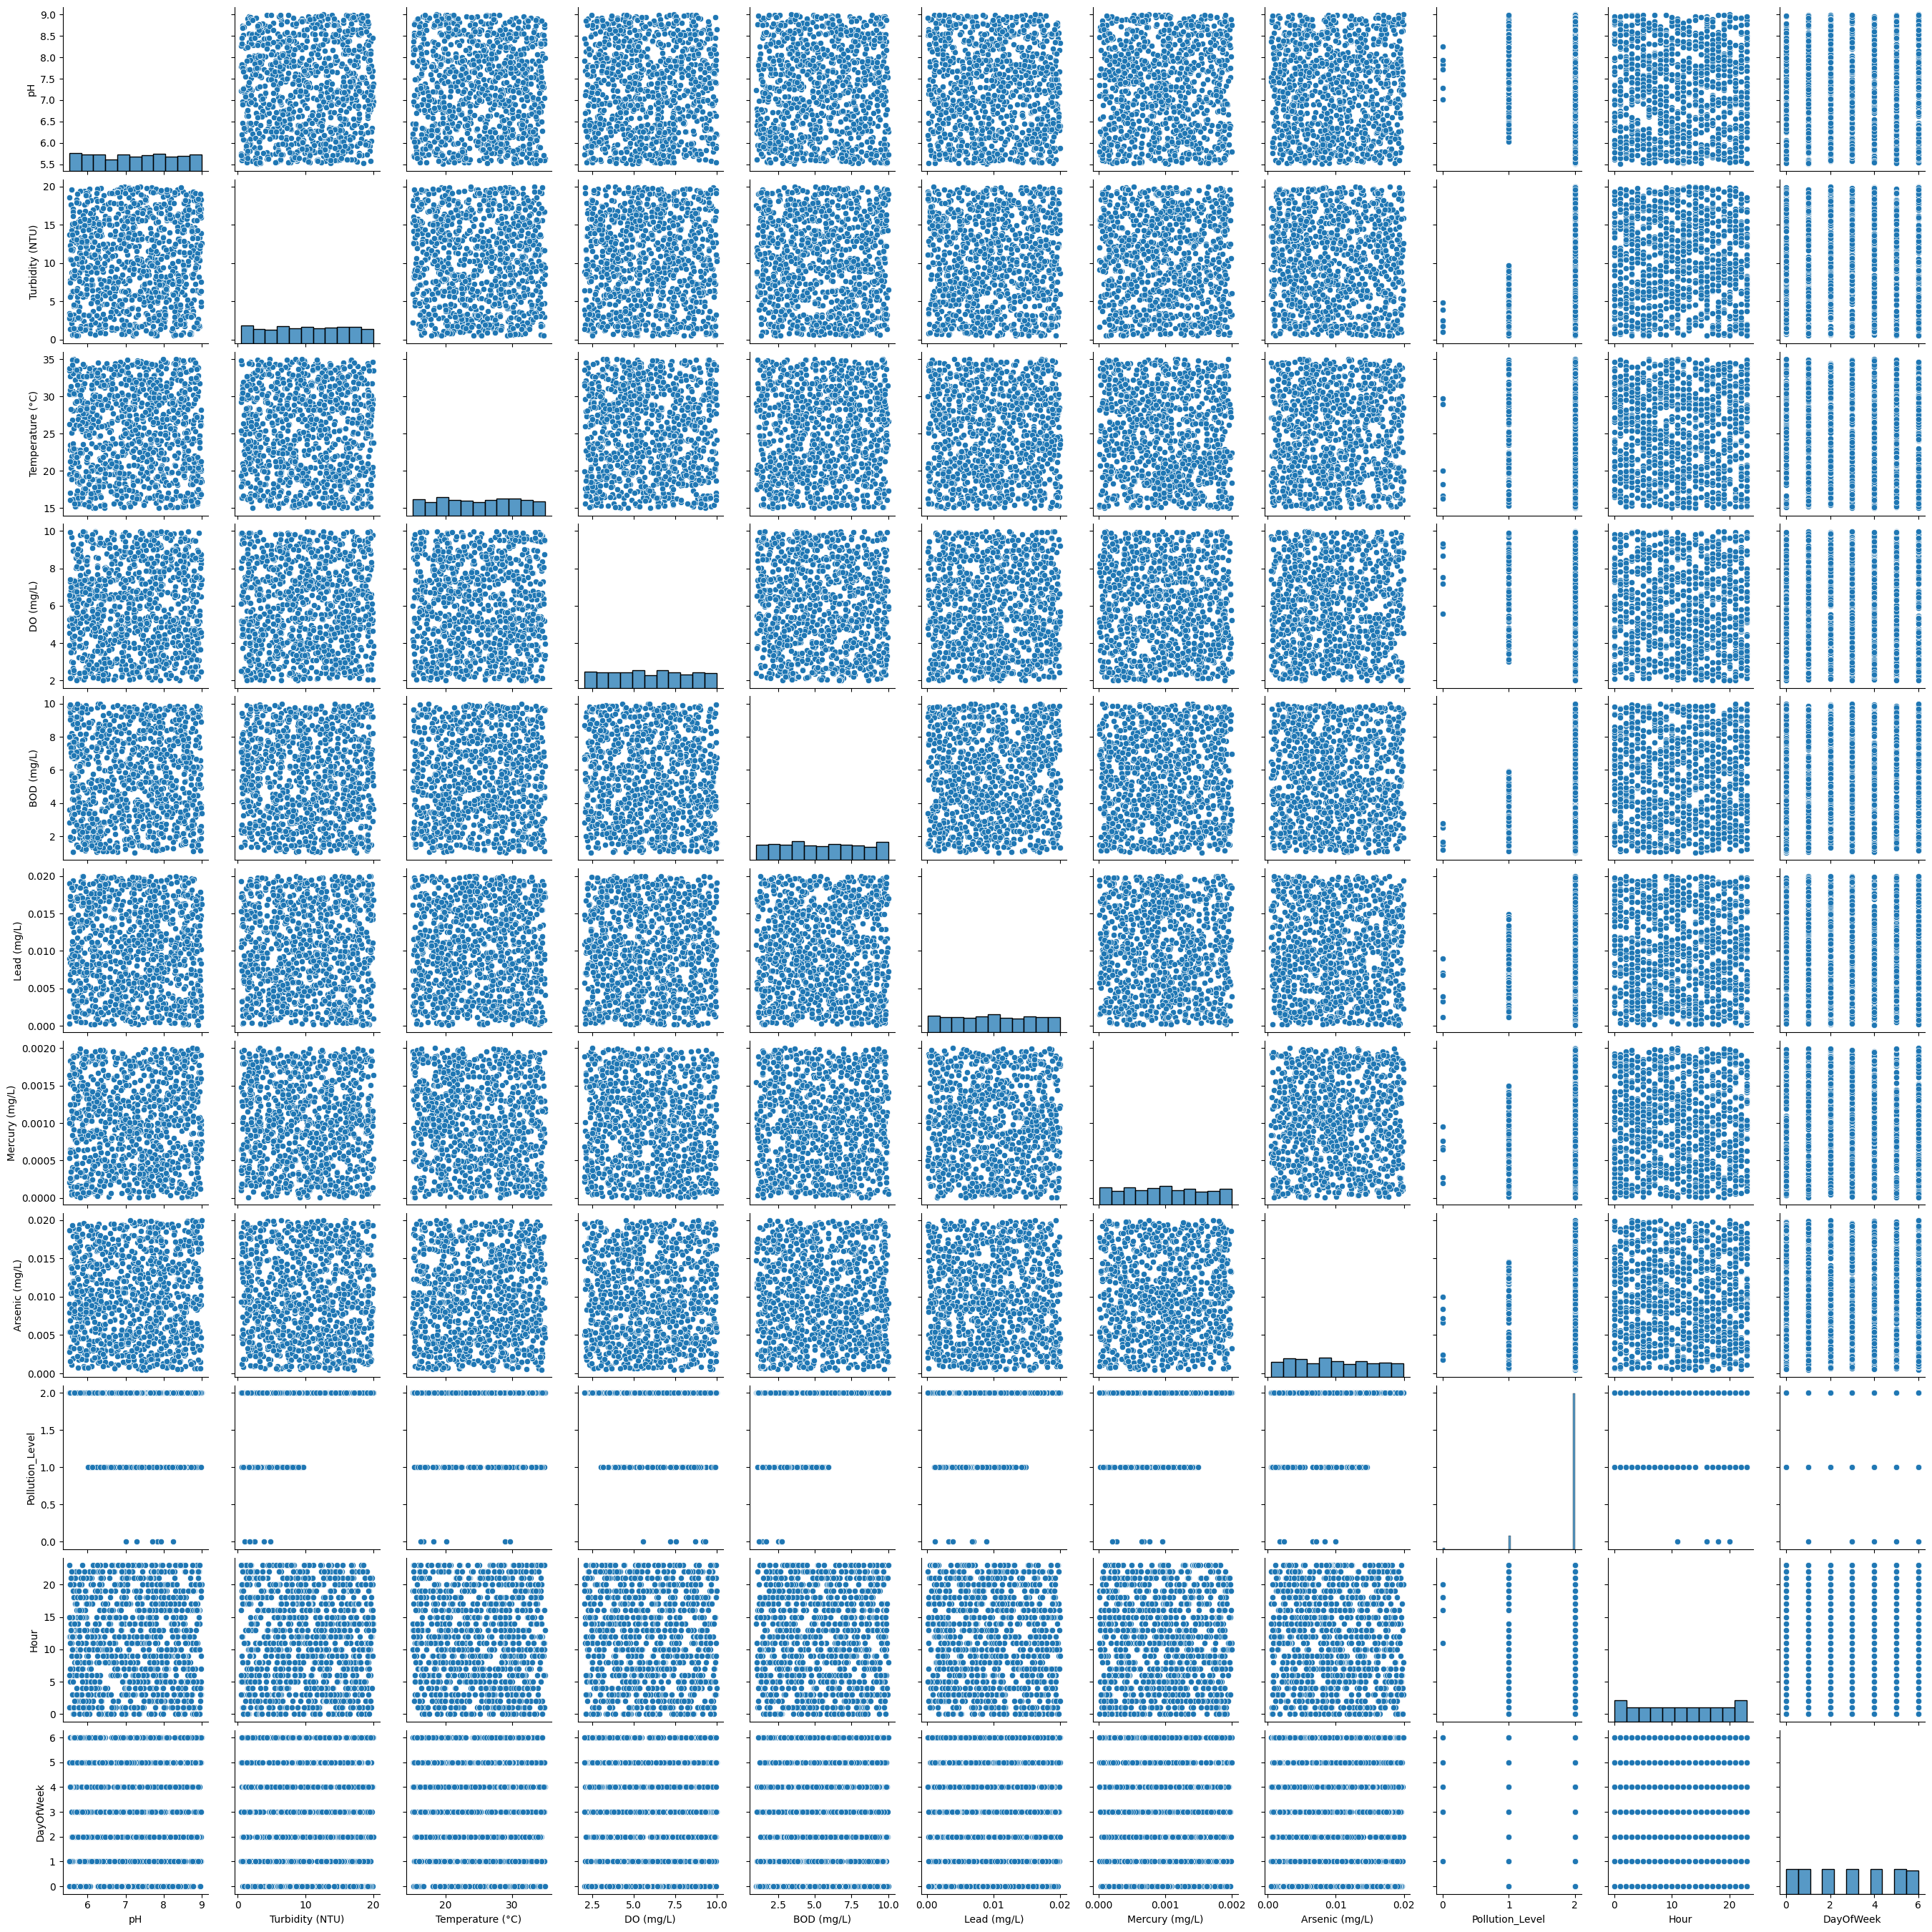

In [9]:
sns.pairplot(df)

<Axes: >

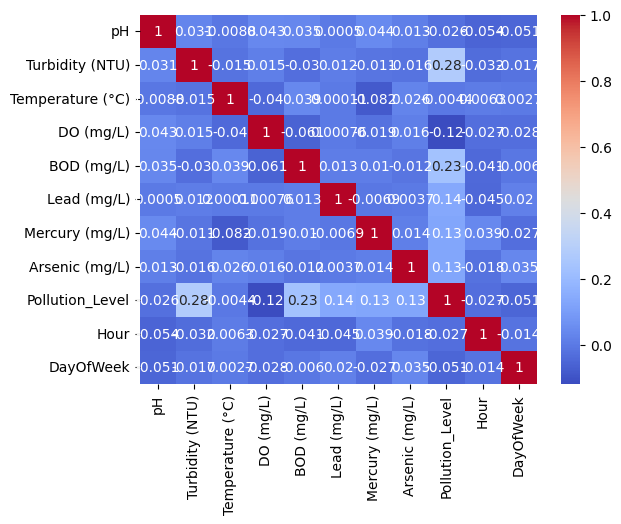

In [10]:

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

In [11]:
df.corr(numeric_only=True)["Pollution_Level"].sort_values(ascending=False)

Pollution_Level     1.000000
Turbidity (NTU)     0.275996
BOD (mg/L)          0.232708
Lead (mg/L)         0.136399
Arsenic (mg/L)      0.127810
Mercury (mg/L)      0.127162
Temperature (°C)   -0.004387
pH                 -0.025698
Hour               -0.027427
DayOfWeek          -0.050921
DO (mg/L)          -0.118351
Name: Pollution_Level, dtype: float64

In [22]:
X = df.drop(columns=['Pollution_Level','Timestamp'])
y = df["Pollution_Level"]
split = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [23]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

In [24]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [25]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

In [26]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": forest_predictions,
    "XGBoost": xgb_predictions
}

for name, predictions in models.items():
    print(name)
    print("Accuracy:", accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))
    print("=" * 50)

Logistic Regression
Accuracy: 0.895
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.25      0.06      0.09        18
           2       0.92      0.98      0.95       181

    accuracy                           0.90       200
   macro avg       0.39      0.35      0.35       200
weighted avg       0.85      0.90      0.87       200

Decision Tree


ValueError: Classification metrics can't handle a mix of multiclass and continuous targets